-----
# AM10 - Computing for Science and Engineering - Module 2

## Homework 06

**Fall 2020**

Handed out: Thursday, Oct. 15, 2020

Due: 11.59 am; Thursday, Oct. 22, 2020

-----

In [213]:
import numpy as np
import matplotlib.pyplot as plt

### Bessel functions and their roots

Bessel functions are special functions that show up as solutions to some common kinds of differential equations. In science and engineering, Bessel functions are especially important for problems in vibrations and wave propagation. For instance, the vibrational modes of a drum membrane can be described using cylindrical Bessel functions, the electric field pattern produced by two radiating charges can be described by spherical Bessel functions. Thus, it is often useful to know the roots of Bessel functions.

The spherical Bessel functions of the first kind of order $n$ are given expression below.

\begin{equation}
j_n(x) =  (-1)^n \left (\frac{d}{dx} \right)^n \frac{\sin{x}}{x}
\end{equation}

where, $\left (\frac{d}{dx} \right)^n$ denotes the $n$-th derivative, so for $n=0$
\begin{equation}
j_0(x) =  \frac{\sin{x}}{x}
\end{equation}
and for $n=1$
\begin{equation}
j_1(x) =  \frac{\sin{x}}{x^2} - \frac{\cos{x}}{x}
\end{equation}

In this assignment, you have to find the roots of the spherical Bessel functions of the second order (i.e. $n=2$).

### Problem 1: Bracketing $j_2(x)$

**Part A:** Define a python function that evaluates the spherical Bessel function of the second order, i.e. $j_2(x)$. You can name the function `j2x`. The input to this function should be the array `x`. Use `j2x` and plot the spherical Bessel function of the second order in the range $1 \le x \le 20$.

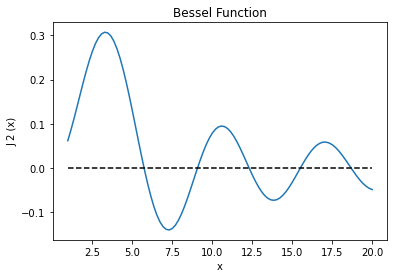

In [214]:
def j2x(x):
    y = (3/x**2-1)*(np.sin(x)/x)-(3*np.cos(x)/(x**2))
    return y 
nx = 100  # define number of points 
xmin = 1  # define range min
xmax = 20  # define range max
x = np.linspace(xmin, xmax, nx)  # generate the array for the independent variable
fx = j2x(x)  # generate the array for the discretized function
plt.plot(x,fx)
plt.xlabel("x")
plt.ylabel('J 2 (x)')
plt.title('Bessel Function')
plt.plot([xmin, xmax], [0, 0], 'k--')
plt.show()

**Part B:** Use your bracketing function, `bracketing_method`, to bracket the roots of $j_2(x)$. Plot the bracket points and the function together in the same figure.

Number of Roots in Interval = 5
Brackets:
5.6060606060606055 5.797979797979798
9.06060606060606 9.252525252525253
12.13131313131313 12.323232323232322
15.393939393939393 15.585858585858585
18.656565656565654 18.848484848484848


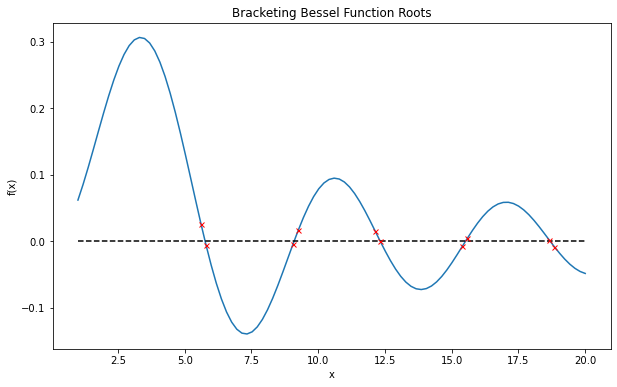

In [215]:
def bracketing_method(x, fx):
  
    # initialize number of roots
    nr = 0
    
    # initialize empty list to hold left brackets
    xa = []
     
    # initialize empty list to hold right brackets
    xb = []
    
    # run loop for all elements of x but last 
    for i in range(len(x)-1):
        # take product of nth and (n+1)th value of fx
        fprod = fx[i] * fx[i+1]
        # check sign for zero-crossing
        if fprod < 0:
            # append lists
            xa.append(x[i])
            xb.append(x[i+1])
            # increment nr
            nr = nr + 1
    # print out results
    print('Number of Roots in Interval =', nr)
    print('Brackets:')
    for i in range(nr):
        print(xa[i], xb[i])
    # return xa, xb, nr
    return xa, xb, nr
# call bracketing_method
xa1, xb1, nr1 = bracketing_method(x, fx)

# Plot fofx and the brackets
fig2, ax2 = plt.subplots(figsize=(10,6))
ax2.plot(x, fx)
ax2.plot([xmin, xmax], [0, 0], 'k--')
for i in range(nr1):
    ax2.plot(xa1[i], j2x(xa1[i]), 'rx', markersize=5)
    ax2.plot(xb1[i], j2x(xb1[i]), 'rx', markersize=5)
ax2.set_xlabel('x')
ax2.set_ylabel('f(x)')
ax2.set_title('Bracketing Bessel Function Roots')
plt.show(fig2)

### Problem 2: Finding Roots of $j_2(x)$
**Part A:** Find the roots of $j_2(x)$ to a tolerance value of 0.001 using the Bisection method. Print out the roots and the number of iterations needed to obtain that root. 

In [216]:
def bisection(f, xa, xb, toler): 
    # maximum number of iterations before exiting the function
    max_iter = 500
    
    # use left bracket as trial root
    xroot = xa
    
    # error at the initial trial root
    ferror = np.absolute(f(xroot))
    
    # initiale number of iterations
    num_iter = 0
    
    # run loop until convergence to the tolerance value
    while ferror > toler:
    
        # check whether maximum iterations have reached
        if num_iter < max_iter:
        
            # generate new trial root by taking mid-point of bracket
            xroot = (xa + xb) / 2

            # check sign for zero-corssing and replace one of the bracket
            frod = f(xroot) * f(xa)
            if frod < 0:
                xb = xroot
            else: 
                xa = xroot
            # recalculate error
            ferror = np.absolute(f(xroot))
            
            # increment number of iterations
            num_iter = num_iter + 1
            
        else:
            print('Maximum Iterations Reached')
            break
        
    # return root and number of iterations
    return xroot, num_iter
#define tolerance
toler = 0.001

# finding roots of j2x
for i in range(nr1):
    xroot, num_iter = bisection(j2x, xa1[i], xb1[i], toler)
    print('Root', i+1, ':', xroot, '-', 'Iterations Needed:', num_iter)

Root 1 : 5.76199494949495 - Iterations Needed: 4
Root 2 : 9.096590909090908 - Iterations Needed: 4
Root 3 : 12.311237373737372 - Iterations Needed: 4
Root 4 : 15.51388888888889 - Iterations Needed: 3
Root 5 : 18.704545454545453 - Iterations Needed: 2


**Part B:** Find the roots of $j_2(x)$ to a tolerance value of 0.001 using the Newton-Raphson method. Use the left bracket value as the trial root. Print out the roots and the number of iterations needed to obtain that root. 

In [217]:
# Derivative Using Central Diff First
def dfdx(f, x0):
    dx = 1e-7  # define dx
    dfdx = (f(x0 + dx) - f(x0 - dx)) / (2 * dx)  # central difference 
    return dfdx
def bracketing_method(x, fx):
    nr = 0  # initialize number of roots
    xa = []  # initialize list to hold left brackets
    xb = []  # initialize list to hold right brackets
    for i in range(len(x) - 1):  # run loop for all elements of x but last 
        fprod = fx[i] * fx[i+1]  
        if fprod < 0:  # check sign for zero-crossing
            xa.append(x[i])
            xb.append(x[i+1])
            nr = nr + 1
    return xa, xb, nr
def newton_raphson(f, xtry, toler):
    max_iter = 500  # maximum number of iterations before exiting the function
    ferror = np.absolute(f(xtry))  # error at the initial guess
    num_iter = 0  # initializing number of iterations

    
    while ferror > toler:  # run loop until convergence to the tolerance value
        if num_iter < max_iter:  # check whether maximum iterations have reached
            df = dfdx(f, xtry)  # call function to compute derivative 
            if np.absolute(df) > 0:  # check whether derivative is zero to avoid divide-by-zero error
                xroot = xtry - f(xtry) / df  # Newton-Raphson update
                ferror = np.absolute(f(xroot))  # current error at new guess
                xtry = xroot  # make new guess the current guess
                num_iter = num_iter + 1  # update number of iterations
            else:
                print('First derivative vanishing')
                break
        else:
            print('Maximum iterations reached without convergance. Exiting loop.')
            break
    return xroot, num_iter
# define tolerance value
toler = 0.001
# finding roots of j2x using Newton-Raphson
for i in range(nr1):
    xtry = xa1[i]  # use left bracket as trial root
    xroot, num_iter = newton_raphson(j2x, xtry, toler)
    print('Root', i+1, ':', xroot, '-', 'Iterations:', num_iter)

Root 1 : 5.760166842964731 - Iterations: 1
Root 2 : 9.094893675493617 - Iterations: 1
Root 3 : 12.32217311108079 - Iterations: 1
Root 4 : 15.514229742604206 - Iterations: 1
Root 5 : 18.688991120674867 - Iterations: 1


**Part C:** Reduce the tolerance value to 1e-12 and now find the roots again using both Bisection and Newton-Raphson. How many iterations do you need for each of the methods.

In [218]:
# USING BISECTION METHOD 
#define tolerance
toler = 1e-12
print('USING THE BISECTION METHOD')
for i in range(nr1):
    xroot, num_iter = bisection(j2x, xa1[i], xb1[i], toler)
    print('Root', i+1, ':', xroot, ',', 'Iterations Needed:', num_iter)

#USING NEWTON-RAPHSON METHOD
print()
print('USING THE NEWTON-RAPHSON METHOD')
# finding roots of j2x using Newton-Raphson
for i in range(nr1):
    xtry = xa1[i]  # use left bracket as trial root
    xroot, num_iter = newton_raphson(j2x, xtry, toler)
    print('Root', i+1, ':', xroot, '-', 'Iterations:', num_iter)

USING THE BISECTION METHOD
Root 1 : 5.763459196892178 , Iterations Needed: 34
Root 2 : 9.095011330484837 , Iterations Needed: 32
Root 3 : 12.322940970566405 , Iterations Needed: 32
Root 4 : 15.514603010893829 , Iterations Needed: 32
Root 5 : 18.689036355356244 , Iterations Needed: 32

USING THE NEWTON-RAPHSON METHOD
Root 1 : 5.763459196893936 - Iterations: 3
Root 2 : 9.095011330476355 - Iterations: 3
Root 3 : 12.322940970566583 - Iterations: 3
Root 4 : 15.514603010886749 - Iterations: 3
Root 5 : 18.689036355362823 - Iterations: 3


### Problem 3: Finding Roots – Limits of Newton-Raphson

**Part A:** Find the roots of the following function using both the Newton-Raphson and Bisection methods.
$$ f(x) = x^3 - 2x + 2 $$
Use $x=0$ as the trial root for Newton-Raphson, and $x=0$ and $x=-3$ as the brackets for Bisection. For the tolerance, use a value of 1e-9. What do you observe? Which method works and which fails?

In [219]:
#NEWTON-RAPHSON
#Define Function
def fofx(x):
    yx=x**3-2*x+2 
    return yx 
nx = 300  # define number of points 
xmin = -3  # define range min
xmax = 1  # define range max
x = np.linspace(xmin, xmax, nx)  # generate the array for the independent variable
z = fofx(x)
# define tolerance value
toler = 1e-9
#find number of roots using bracketing method
xaz, xbz, nrz = bracketing_method(x, z)
#nrz is number of roots of my function z above 
# finding roots of fofx using Newton-Raphson
for i in range (nrz):
    xtry = 0  # use x=0 as trial root
    xroot, num_iter = newton_raphson(fofx, xtry, toler)
    print('Root', i+1, ':', xroot, '-', 'Iterations:', num_iter)

#BISECTION 
print()
# finding roots of fofx using Bisection 
for i in range (nrz):
    xroot, num_iter = bisection(fofx, 0, -3, toler)
    print('Root', i+1, ':', xroot, '-', 'Iterations Needed:', num_iter)
print("I observe that the Newton-Raphson Method does not converge. The Bisection method works, while the Newton-Raphson method fails.")

Maximum iterations reached without convergance. Exiting loop.
Root 1 : 5.838671768287895e-10 - Iterations: 500

Root 1 : -1.7692923542344943 - Iterations Needed: 33
I observe that the Newton-Raphson Method does not converge. The Bisection method works, while the Newton-Raphson method fails.


**Part B:** Try the Newton-Raphson method again, use the following trial roots $x=-0.1$, $-0.5$, $0.1$, $0.5$, $-1$, and $1$, and the same tolerance as above. Which trial roots work?

In [220]:
# -0.1 root 
print('Trying X = -0.1:')
for i in range (nrz):
    xtry = -0.1  # use x=-0.1 as trial root
    xroot, num_iter = newton_raphson(fofx, xtry, toler)
    print(xroot, '-', 'Iterations:', num_iter)
    print()
# -0.5 root 
print('Trying X = -0.5:')
for i in range (nrz):
    xtry = -0.5  # use x=-0.5 as trial root
    xroot, num_iter = newton_raphson(fofx, xtry, toler)
    print(xroot, '-', 'Iterations:', num_iter)
    print()
# 0.1 root 
print('Trying X = 0.1:')
for i in range (nrz):
    xtry = 0.1  # use x=0.1 as trial root
    xroot, num_iter = newton_raphson(fofx, xtry, toler)
    print(xroot, '-', 'Iterations:', num_iter)
    print()
# 0.5 root 
print('Trying X = 0.5:')
for i in range (nrz):
    xtry = 0.5  # use x=0.5 as trial root
    xroot, num_iter = newton_raphson(fofx, xtry, toler)
    print(xroot, '-', 'Iterations:', num_iter)
    print()
# -1.0 root 
print('Trying X = -1.0:')
for i in range (nrz):
    xtry = -1.0  # use x=-0.1 as trial root
    xroot, num_iter = newton_raphson(fofx, xtry, toler)
    print(xroot, '-', 'Iterations:', num_iter)
    print()
# 1 root 
print('Trying X = 1:')
for i in range (nrz):
    xtry = 1 # use x=1 as trial root
    xroot, num_iter = newton_raphson(fofx, xtry, toler)
    print(xroot, '-', 'Iterations:', num_iter)
    print()
print("The trial roots that work are 0.5 and -1 ")

Trying X = -0.1:
Maximum iterations reached without convergance. Exiting loop.
5.838671768287895e-10 - Iterations: 500

Trying X = -0.5:
Maximum iterations reached without convergance. Exiting loop.
0.9999999999712443 - Iterations: 500

Trying X = 0.1:
Maximum iterations reached without convergance. Exiting loop.
5.838671768287895e-10 - Iterations: 500

Trying X = 0.5:
-1.7692923542513417 - Iterations: 8

Trying X = -1.0:
-1.769292354297361 - Iterations: 7

Trying X = 1:
Maximum iterations reached without convergance. Exiting loop.
0.9999999999712443 - Iterations: 500

The trial roots that work are 0.5 and -1 


***Optional Part C:*** Why does the Newton-Raphson method fail when certain trial roots are used? Write a brief explanation.
*Hint:* Plot the function and try to follow-through with the first few iterations of Newton-Raphson, to see what's going on.

The Newton-Raphson method fails when certain trial roots are used because if our first guess, or a later guess, is a point at which there is a horizontal tangent line, then this line will never hit the x-axis, and Newton's Method will fail to locate the root. Furthermore, a trial root can fail if there are multiple roots, in which case we must have our first guess near the root that we want, otherwise Newton's method will find the wrong root! There are many ways to get a guess to diverge, but you can try to avoid that by using an accurate guess by using a bracketing method with a lot of points for example.


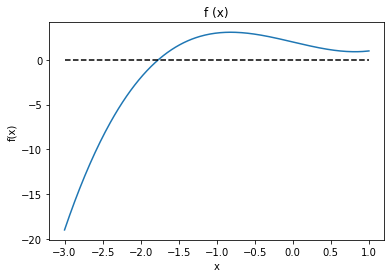

In [222]:
plt.plot(x,fofx(x))
plt.xlabel("x")
plt.ylabel('f(x)')
plt.title('f (x)')
plt.plot([xmin, xmax], [0, 0], 'k--')
print("The Newton-Raphson method fails when certain trial roots are used because if our first guess, or a later guess, is a point at which there is a horizontal tangent line, then this line will never hit the x-axis, and Newton's Method will fail to locate the root. Furthermore, a trial root can fail if there are multiple roots, in which case we must have our first guess near the root that we want, otherwise Newton's method will find the wrong root! There are many ways to get a guess to diverge, but you can try to avoid that by using an accurate guess by using a bracketing method with a lot of points for example.")